In [1]:
!pip install scikit-learn joblib

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import matplotlib.pyplot as plt

import joblib

In [5]:
notebook_dir = Path.cwd()

candidate_paths = [
    notebook_dir / "data/processed/feature_engineered.csv",
    notebook_dir.parent / "data/processed/feature_engineered.csv",
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        f"Could not find MBA.csv. Checked: {', '.join(str(path) for path in candidate_paths)}"
    )

df = pd.read_csv(data_path)

print("Shape:", df.shape)

df.head()

Shape: (6194, 10)


,international,gpa,major,gmat,work_exp,work_industry,target,academic_index,experience_level,gpa_gmat_score
0,0,3.30,Business,620.0,3.0,Financial Services,1,392.0,Junior,2046.0
1,0,3.28,Humanities,680.0,5.0,Investment Management,0,396.0,Mid,2230.4
2,1,3.30,Business,710.0,5.0,Technology,1,401.0,Mid,2343.0
3,0,3.47,STEM,690.0,6.0,Technology,0,416.0,Mid,2394.3
4,0,3.35,STEM,590.0,5.0,Consulting,0,394.0,Mid,1976.5


In [6]:
X = df.drop(columns=["target"])

y = df["target"]

In [7]:
categorical_features = [
    "major",
    "work_industry",
    "experience_level"
]

numeric_features = [
    "international",
    "gpa",
    "gmat",
    "work_exp",
    "academic_index",
    "gpa_gmat_score"
]

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

Categorical: ['major', 'work_industry', 'experience_level']
Numeric: ['international', 'gpa', 'gmat', 'work_exp', 'academic_index', 'gpa_gmat_score']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4955, 9)
(1239, 9)


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

In [11]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

In [12]:
pipeline.fit(
    X_train,
    y_train
)

print("Training complete")

Training complete


In [13]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

In [14]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.738498789346247


In [15]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.71      0.82      1059
           1       0.35      0.90      0.50       180

    accuracy                           0.74      1239
   macro avg       0.66      0.81      0.66      1239
weighted avg       0.89      0.74      0.78      1239



In [16]:
roc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc)

ROC-AUC: 0.8152712202287271


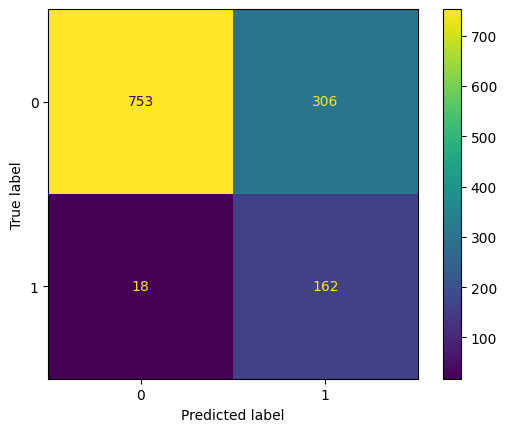

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [18]:
from pathlib import Path
import joblib

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "best_model.pkl"

joblib.dump(
    pipeline,
    model_path
)

print(f"Model saved to {model_path.resolve()}")

Model saved to C:\Users\ASUS\OneDrive\Documents\Kuliah\Semester 6\Sistem Pendukung Keputusan\Tugas 4\University Admission DSS\models\best_model.pkl


In [19]:
# Get trained RF model
rf = pipeline.named_steps["model"]

# Get feature names after encoding
feature_names = (
    pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Importance dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
22,remainder__gmat,0.279619
25,remainder__gpa_gmat_score,0.265772
24,remainder__academic_index,0.176905
21,remainder__gpa,0.148494
23,remainder__work_exp,0.023047
20,remainder__international,0.015595
0,cat__major_Business,0.008206
1,cat__major_Humanities,0.008114
2,cat__major_STEM,0.007877
11,cat__work_industry_Nonprofit/Gov,0.007601


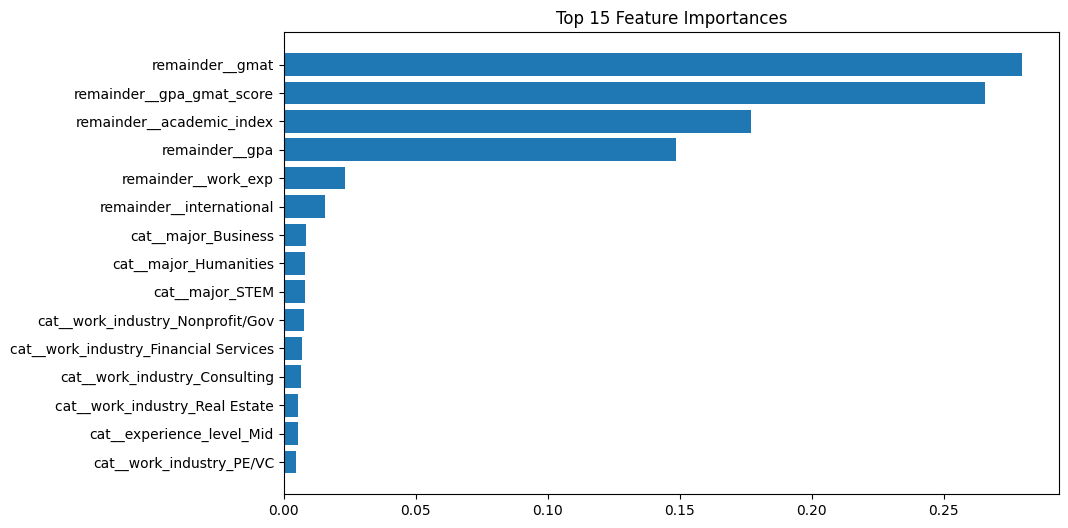

In [20]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("Top 15 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [21]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "feature_importance.csv"

df.to_csv(
    output_path,
    index=False
)

print(f"Feature importance data saved to {output_path.resolve()}")

Feature importance data saved to C:\Users\ASUS\OneDrive\Documents\Kuliah\Semester 6\Sistem Pendukung Keputusan\Tugas 4\University Admission DSS\data\processed\feature_importance.csv
